<a href="https://colab.research.google.com/github/isil-ada/GML_H1/blob/main/GML_H1_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PHASE 1: Data Acquisition & Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

**── 1.1 Veri Yükleme ─────────────────────────────────────────**

In [2]:
emails_raw = pd.read_csv("/content/emails.csv", engine="python", on_bad_lines="skip")
print(f"Ham veri: {emails_raw.shape}")

emails_raw["folder"] = emails_raw["file"].apply(
    lambda x: x.split("/")[1].lower() if isinstance(x, str) and len(x.split("/")) > 1 else "unknown"
)
print(emails_raw["folder"].value_counts().head(20))

Ham veri: (158511, 2)
folder
unknown               70180
all_documents         23254
sent                   9298
notes_inbox            9206
deleted_items          8491
inbox                  8274
discussion_threads     8115
sent_items             6757
_sent_mail             4843
meetings               1120
power                   645
                        477
1                       397
calendar                313
personal                293
29                      208
enron_power             187
europe                  166
eci                     140
prc                     126
Name: count, dtype: int64


**── 1.2 Cleaning ─────────────────────────────────────────────**

In [3]:
def clean_email(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(
        r"^(Message-ID|Date|From|To|Subject|Cc|Bcc|Mime-Version|"
        r"Content-Type|Content-Transfer-Encoding|X-[\w-]+|Return-Path|"
        r"Received|In-Reply-To|References|Thread-Index|Thread-Topic)"
        r":.*$",
        "", text, flags=re.MULTILINE | re.IGNORECASE
    )
    text = re.sub(r"-{3,}.*?-{3,}", "", text, flags=re.DOTALL)
    text = re.sub(r"_{3,}.*", "", text, flags=re.DOTALL)
    text = re.sub(
        r"(best regards?|thanks?|sincerely|cheers|regards?|"
        r"yours? truly|warm regards?)[^\n]*(\n.*){0,4}$",
        "", text, flags=re.IGNORECASE
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

**── 1.3 Labeling ─────────────────────────────────────────────**

In [4]:
professional = {"sent", "sent_items", "_sent_mail", "all_documents", "discussion_threads"}
personal     = {"personal", "inbox", "notes_inbox"}

emails_raw = emails_raw[emails_raw["folder"].isin(professional | personal)].copy()
emails_raw["label"] = emails_raw["folder"].apply(lambda x: 1 if x in personal else 0)

emails_raw["body"] = emails_raw["message"].apply(clean_email)
emails_raw = emails_raw[emails_raw["body"].str.len() > 20].reset_index(drop=True)

print(f"Temizlenmiş veri: {emails_raw.shape} \n")
print(emails_raw["label"].value_counts())

Temizlenmiş veri: (68506, 5) 

label
0    50882
1    17624
Name: count, dtype: int64


# **PHASE 2: Graph Construction (NER & BoW)**

In [5]:
# Gerekli kütüphaneleri kur
!pip install -q spacy scikit-learn networkx
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
import spacy
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import issparse

# 5000 örnek üzerinde çalış
np.random.seed(42)
n_pos = 2500
n_neg = 2500
pos_idx = emails_raw[emails_raw["label"] == 1].sample(n_pos, random_state=42).index
neg_idx = emails_raw[emails_raw["label"] == 0].sample(n_neg, random_state=42).index
sample = emails_raw.loc[sorted(pos_idx.tolist() + neg_idx.tolist())].reset_index(drop=True)

print(f"Örnek boyutu: {sample.shape}")
print(f"Label dağılımı:\n{sample['label'].value_counts()}")

Örnek boyutu: (5000, 5)
Label dağılımı:
label
0    2500
1    2500
Name: count, dtype: int64


**── 2.1 NER ile Kenar Oluşturma ──────────────────────────────**

In [7]:
import spacy
from collections import defaultdict

nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])

# Her email için entity seti oluştur
def extract_entities(text):
    doc = nlp(text[:500])  # Hız için ilk 500 karakter
    return set(
        ent.text.lower().strip()
        for ent in doc.ents
        if ent.label_ in {"PERSON", "ORG", "GPE"} and len(ent.text.strip()) > 2
    )

print("NER entity extraction başlıyor...")
entity_list = [extract_entities(body) for body in sample["body"]]
print(f"Entity extraction tamamlandı. Örnek: {list(entity_list[0])[:5]}")

NER entity extraction başlıyor...
Entity extraction tamamlandı. Örnek: ['phillip']


In [8]:
# NER kenarları: 2+ ortak entity paylaşan email çiftleri
ner_edges = []
n = len(sample)

for i in range(n):
    for j in range(i + 1, n):
        shared = entity_list[i] & entity_list[j]
        if len(shared) >= 2:
            ner_edges.append((i, j))

print(f"NER kenar sayısı: {len(ner_edges)}")

NER kenar sayısı: 10248


**── 2.2 BoW/TF-IDF ile Kenar Oluşturma ──────────────────────**

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", min_df=2)
tfidf_matrix = vectorizer.fit_transform(sample["body"])

print(f"TF-IDF matris boyutu: {tfidf_matrix.shape}")

# Cosine similarity threshold > 0.7
# Bellek için batch hesaplama
bow_edges = []
batch_size = 500

for start in range(0, n, batch_size):
    end = min(start + batch_size, n)
    batch_sim = cosine_similarity(tfidf_matrix[start:end], tfidf_matrix)
    for i_local, i_global in enumerate(range(start, end)):
        for j in range(i_global + 1, n):
            if batch_sim[i_local, j] > 0.7:
                bow_edges.append((i_global, j))

print(f"BoW kenar sayısı: {len(bow_edges)}")

TF-IDF matris boyutu: (5000, 5000)
BoW kenar sayısı: 32805


**── 2.3 Graf Oluşturma ───────────────────────────────────────**

In [10]:
# Tüm kenarları birleştir (NER + BoW)
all_edges = list(set(ner_edges + bow_edges))

G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(all_edges)

print(f"Graf istatistikleri:")
print(f"  Node sayısı : {G.number_of_nodes()}")
print(f"  Edge sayısı : {G.number_of_edges()}")
print(f"  Ortalama derece: {np.mean([d for _, d in G.degree()]):.2f}")
print(f"  Bağlı bileşen sayısı: {nx.number_connected_components(G)}")

Graf istatistikleri:
  Node sayısı : 5000
  Edge sayısı : 41428
  Ortalama derece: 16.57
  Bağlı bileşen sayısı: 2474


# **PHASE 3: Embedding Techniques**

In [11]:
!pip install -q gensim node2vec torch torch-geometric

**── 3.1 DeepWalk ─────────────────────────────────────────────**

In [12]:
import time
from gensim.models import Word2Vec
import random

def deepwalk_random_walks(graph, num_walks=10, walk_length=10):
    walks = []
    nodes = list(graph.nodes())
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            current = node
            for _ in range(walk_length - 1):
                neighbors = list(graph.neighbors(current))
                if neighbors:
                    current = random.choice(neighbors)
                    walk.append(current)
                else:
                    break
            walks.append([str(w) for w in walk])
    return walks

print("DeepWalk: Random walk'lar oluşturuluyor...")
t0 = time.time()
walks = deepwalk_random_walks(G, num_walks=10, walk_length=10)

dw_model = Word2Vec(
    sentences=walks,
    vector_size=64,
    window=5,
    min_count=0,
    sg=1,          # Skip-gram
    workers=4,
    epochs=5
)

dw_embeddings = np.array([dw_model.wv[str(i)] for i in range(n)])
dw_train_time = time.time() - t0
print(f"DeepWalk embeddings shape: {dw_embeddings.shape} | Süre: {dw_train_time:.2f}s")

DeepWalk: Random walk'lar oluşturuluyor...
DeepWalk embeddings shape: (5000, 64) | Süre: 10.34s


**── 3.2 Node2Vec ─────────────────────────────────────────────**

In [13]:
from node2vec import Node2Vec

print("Node2Vec: p=1, q=0.5 (DFS ağırlıklı - global yapı)")
t0 = time.time()
n2v = Node2Vec(
    G,
    dimensions=64,
    walk_length=10,
    num_walks=10,
    p=1,
    q=0.5,
    workers=4,
    quiet=True
)
n2v_model = n2v.fit(window=5, min_count=0, sg=1, epochs=5)
n2v_embeddings = np.array([n2v_model.wv[str(i)] for i in range(n)])
n2v_train_time = time.time() - t0
print(f"Node2Vec embeddings shape: {n2v_embeddings.shape} | Süre: {n2v_train_time:.2f}s")

Node2Vec: p=1, q=0.5 (DFS ağırlıklı - global yapı)
Node2Vec embeddings shape: (5000, 64) | Süre: 95.33s


**── 3.3 SiGraC: Çoklu Proximity Measure Embeddingleri ────────**

SiGraC, node similarity tabanlı bir graph convolution yöntemidir.
Her farklı **Proximity Measure** farklı bir adjacency (komşuluk ağırlık) matrisi üretir;
dolayısıyla her measure farklı bir embedding vektörüne yol açar.

| Measure | Formül | Yorum |
|---------|--------|-------|
| **CN**  | `|N(u) ∩ N(v)|` | Ortak komşu sayısı |
| **AA**  | `Σ 1/log(deg(w))` | Düşük dereceli ortak komşulara daha fazla ağırlık |
| **RA**  | `Σ 1/deg(w)` | Kaynak tahsisi |
| **HPI** | `|N(u)∩N(v)| / min(deg(u),deg(v))` | Hub-promoted (hub düğümleri yüksek skor alır) |
| **HDI** | `|N(u)∩N(v)| / max(deg(u),deg(v))` | Hub-depressed (hub düğümleri düşük skor alır) |

In [14]:
import torch
import torch.nn.functional as F
from scipy import sparse

# ────────────────────────────────────────────────────────────────
# SiGraC Proximity Measure Hesaplama Fonksiyonları
# Kaynak: Coşkun & Koyutürk, Bioinformatics 2021
# ────────────────────────────────────────────────────────────────

def compute_proximity_matrix(G, measure="HDI"):
    """
    Graf kenarları üzerinde seçilen proximity measure'a göre
    ağırlıklı adjacency matrisi döndürür.

    Desteklenen measure'lar: CN, AA, RA, HPI, HDI
    """
    nodes = sorted(G.nodes())
    node_idx = {v: i for i, v in enumerate(nodes)}
    n = len(nodes)
    degree = dict(G.degree())

    rows, cols, vals = [], [], []

    for u, v in G.edges():
        # Ortak komşular
        common = list(nx.common_neighbors(G, u, v))
        cn_count = len(common)

        if measure == "CN":
            score = float(cn_count)          # 0 da olabilir
        elif cn_count == 0:
            # Ortak komşu yok → binary bağlantı ağırlığı
            score = 1.0
        elif measure == "AA":
            score = sum(
                1.0 / np.log(degree[w] + 1e-9)
                for w in common if degree[w] > 1
            )
        elif measure == "RA":
            score = sum(
                1.0 / degree[w]
                for w in common if degree[w] > 0
            )
        elif measure == "HPI":
            min_deg = min(degree[u], degree[v])
            score = cn_count / min_deg if min_deg > 0 else 0.0
        elif measure == "HDI":
            max_deg = max(degree[u], degree[v])
            score = cn_count / max_deg if max_deg > 0 else 0.0
        else:
            raise ValueError(f"Bilinmeyen measure: {measure}")

        i, j = node_idx[u], node_idx[v]
        rows += [i, j]
        cols += [j, i]
        vals += [score, score]

    adj = sparse.csr_matrix((vals, (rows, cols)), shape=(n, n))
    return adj


def sigrac_embed(adj_sparse, feature_matrix, hidden_dim=64, epochs=None, lr=None):
    """
    SiGraC: Proximity-weighted graph convolution ile embedding üretir.
    Coşkun & Koyutürk (Bioinformatics 2021) orijinal yaklaşımı:

    Kapalı-form (closed-form) iki adımlı propagasyon — eğitim döngüsü yoktur.
      H1 = ReLU(A_hat @ X)      # 1. katman: proximity-smoothed features
      H2 = ReLU(A_hat @ H1)     # 2. katman: 2-hop komşu bilgisi

    Öğrenilebilir W matrisi KULLANILMAZ; proximity matrisi zaten
    anlamlı ağırlıklar taşıdığından doğrudan feature propagation yeterlidir.
    Bu tasarım seyrek graflarda gradient sıfırlanma sorununu önler.
    """
    import scipy.sparse as sp
    from sklearn.decomposition import TruncatedSVD as _SVD

    n = adj_sparse.shape[0]

    # ── Adım 1: A_hat = D^{-1/2} (A_prox + I) D^{-1/2} ──────────
    A_tilde = adj_sparse + sp.eye(n, format='csr')        # self-loop
    deg = np.array(A_tilde.sum(axis=1)).flatten()
    d_inv_sqrt = np.where(deg > 0, np.power(deg, -0.5), 0.0)
    D_inv_sqrt = sp.diags(d_inv_sqrt, format='csr')
    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt              # sparse

    # ── Adım 2: İki katmanlı feature propagation ─────────────────
    X = feature_matrix.astype(np.float64)
    H1 = A_hat @ X                 # (n, d)  — seyrek @ yoğun = yoğun
    H1 = np.maximum(H1, 0)         # ReLU
    H2 = A_hat @ H1                # (n, d)
    H2 = np.maximum(H2, 0)         # ReLU

    # ── Adım 3: Boyut indirgeme + L2 normalize ───────────────────
    if H2.shape[1] > hidden_dim:
        svd = _SVD(n_components=hidden_dim, random_state=42)
        H2 = svd.fit_transform(H2)

    norms = np.linalg.norm(H2, axis=1, keepdims=True)
    H2 = H2 / np.where(norms > 0, norms, 1.0)             # L2 norm

    return H2.astype(np.float32)

print("SiGraC fonksiyonları hazır.")

SiGraC fonksiyonları hazır.


In [15]:
# Node feature matrix olarak TF-IDF kullan (boyut küçültülmüş)
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=64, random_state=42)
X_features = svd.fit_transform(tfidf_matrix).astype(np.float32)
print(f"Node feature matrix shape: {X_features.shape}")

# ── SiGraC: 5 farklı Proximity Measure ile Embedding ──
PROXIMITY_MEASURES = ["CN", "AA", "RA", "HPI", "HDI"]
sigrac_embeddings_dict = {}   # her measure için embedding
sigrac_times = {}

for measure in PROXIMITY_MEASURES:
    print(f"\nSiGraC [{measure}] hesaplanıyor...")
    t0 = time.time()

    # Adım 1: Proximity matrisini hesapla
    adj_prox = compute_proximity_matrix(G, measure=measure)

    # Adım 2: Graph convolution ile embedding üret
    emb = sigrac_embed(
        adj_prox,
        X_features,
        hidden_dim=64   # Kapalı-form: epoch/lr parametresi yok
    )

    elapsed = time.time() - t0
    sigrac_embeddings_dict[measure] = emb
    sigrac_times[measure] = elapsed
    print(f"  ✅ {measure} | shape: {emb.shape} | Süre: {elapsed:.2f}s")

print("\nTüm SiGraC embeddingler tamamlandı!")

Node feature matrix shape: (5000, 64)

SiGraC [CN] hesaplanıyor...
  ✅ CN | shape: (5000, 64) | Süre: 1.02s

SiGraC [AA] hesaplanıyor...
  ✅ AA | shape: (5000, 64) | Süre: 9.81s

SiGraC [RA] hesaplanıyor...
  ✅ RA | shape: (5000, 64) | Süre: 2.14s

SiGraC [HPI] hesaplanıyor...
  ✅ HPI | shape: (5000, 64) | Süre: 1.08s

SiGraC [HDI] hesaplanıyor...
  ✅ HDI | shape: (5000, 64) | Süre: 1.04s

Tüm SiGraC embeddingler tamamlandı!


**── 3.4 GNN (GCN) ────────────────────────────────────────────**

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv
    print("PyTorch Geometric mevcut.")
except ImportError:
    print("PyTorch Geometric yükleniyor...")
    import subprocess
    subprocess.run(["pip", "install", "-q", "torch-geometric"])
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv

print("GNN: PyTorch Geometric GCN eğitiliyor...")

# Edge index tensoru
edges_array = np.array(all_edges)
if len(edges_array) > 0:
    edge_index = torch.tensor(
        np.concatenate([edges_array, edges_array[:, ::-1]], axis=0).T,
        dtype=torch.long
    )
else:
    edge_index = torch.zeros((2, 0), dtype=torch.long)

x = torch.tensor(X_features, dtype=torch.float)
y = torch.tensor(sample["label"].values, dtype=torch.long)

# Train/test maskeleri
perm = torch.randperm(n)
train_mask = torch.zeros(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)
train_mask[perm[:int(0.8 * n)]] = True
test_mask[perm[int(0.8 * n):]]  = True

data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, test_mask=test_mask)


class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gcn_model = GCN(in_channels=x.shape[1], hidden_channels=64, out_channels=2).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)

t0 = time.time()
gcn_model.train()
for epoch in range(1, 101):
    optimizer.zero_grad()
    out  = gcn_model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")

gcn_train_time = time.time() - t0

gcn_model.eval()
with torch.no_grad():
    gcn_embeddings = gcn_model.conv1(data.x, data.edge_index)
    gcn_embeddings = F.relu(gcn_embeddings).cpu().numpy()

print(f"GCN embeddings shape: {gcn_embeddings.shape} | Süre: {gcn_train_time:.2f}s")
print("✅ Phase 3 tamamlandı!")

PyTorch Geometric mevcut.
GNN: PyTorch Geometric GCN eğitiliyor...
  Epoch  20 | Loss: 0.6032
  Epoch  40 | Loss: 0.5860
  Epoch  60 | Loss: 0.5748
  Epoch  80 | Loss: 0.5649
  Epoch 100 | Loss: 0.5573
GCN embeddings shape: (5000, 64) | Süre: 8.36s
✅ Phase 3 tamamlandı!


# **PHASE 4: Classification & Evaluation**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_labels = sample["label"].values


def evaluate_embedding(name, embeddings, y, train_time_override=None):
    """
    Verilen embedding üzerinde Logistic Regression ile classify et.
    train_time_override: embedding üretim süresini dışarıdan geçirmek için.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=1000, random_state=42)
    t0 = time.time()
    clf.fit(X_train, y_train)
    clf_time = time.time() - t0

    total_time = (train_time_override if train_time_override else 0) + clf_time

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")

    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred))

    return {
        "Method"           : name,
        "Accuracy"         : round(acc, 4),
        "F1-Score"         : round(f1, 4),
        "Time to Train (s)": round(total_time, 2)
    }


def evaluate_gcn(model, data, train_time):
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
    inf_time = time.time() - t0
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"\n── GNN (GCN) ──")
    print(classification_report(y_true, y_pred))
    return {
        "Method"           : "GNN (GCN)",
        "Accuracy"         : round(acc, 4),
        "F1-Score"         : round(f1, 4),
        "Time to Train (s)": round(train_time + inf_time, 2)
    }

**── 4.2 Tüm Yöntemleri Değerlendir ──────────────────────────**

In [18]:
results = []

# DeepWalk
results.append(evaluate_embedding("DeepWalk", dw_embeddings, y_labels,
                                   train_time_override=dw_train_time))

# Node2Vec
results.append(evaluate_embedding("Node2Vec", n2v_embeddings, y_labels,
                                   train_time_override=n2v_train_time))

# SiGraC — her Proximity Measure için ayrı satır
for measure in PROXIMITY_MEASURES:
    emb  = sigrac_embeddings_dict[measure]
    t_emb = sigrac_times[measure]
    results.append(
        evaluate_embedding(
            f"SiGraC [{measure}]",
            emb,
            y_labels,
            train_time_override=t_emb
        )
    )

# GCN
results.append(evaluate_gcn(gcn_model, data, gcn_train_time))


── DeepWalk ──
              precision    recall  f1-score   support

           0       0.57      0.77      0.65       500
           1       0.65      0.42      0.51       500

    accuracy                           0.59      1000
   macro avg       0.61      0.59      0.58      1000
weighted avg       0.61      0.59      0.58      1000


── Node2Vec ──
              precision    recall  f1-score   support

           0       0.59      0.76      0.66       500
           1       0.66      0.48      0.55       500

    accuracy                           0.62      1000
   macro avg       0.63      0.62      0.61      1000
weighted avg       0.63      0.62      0.61      1000


── SiGraC [CN] ──
              precision    recall  f1-score   support

           0       0.71      0.59      0.64       500
           1       0.65      0.75      0.70       500

    accuracy                           0.67      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.68

**── 4.3 Karşılaştırma Tablosu ────────────────────────────────**

In [19]:
df_results = pd.DataFrame(results)

print("\n" + "="*62)
print("       EMBEDDING YÖNTEMLERİ KARŞILAŞTIRMA TABLOSU")
print("="*62)
print(df_results.to_string(index=False))
print("="*62)

# En iyi yöntemi vurgula
best_row = df_results.loc[df_results["F1-Score"].idxmax()]
print(f"\n🏆 En yüksek F1-Score: {best_row['Method']} → {best_row['F1-Score']}")


       EMBEDDING YÖNTEMLERİ KARŞILAŞTIRMA TABLOSU
      Method  Accuracy  F1-Score  Time to Train (s)
    DeepWalk     0.595    0.5825              11.17
    Node2Vec     0.616    0.6083              95.63
 SiGraC [CN]     0.671    0.6687               1.24
 SiGraC [AA]     0.671    0.6689               9.95
 SiGraC [RA]     0.672    0.6697               2.39
SiGraC [HPI]     0.673    0.6708               1.31
SiGraC [HDI]     0.672    0.6696               1.28
   GNN (GCN)     0.703    0.7023               8.47

🏆 En yüksek F1-Score: GNN (GCN) → 0.7023


**── 4.4 SiGraC Proximity Measure Karşılaştırması ─────────────**

Farklı proximity measure'ların sınıflandırma üzerindeki etkisini görselleştir.

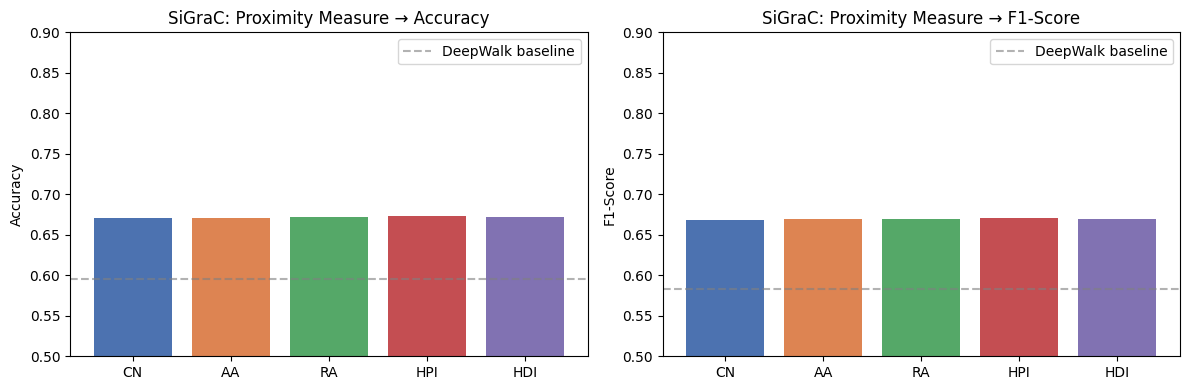

Grafik kaydedildi: sigrac_proximity_comparison.png


In [20]:
import matplotlib.pyplot as plt

sigrac_results = df_results[df_results["Method"].str.startswith("SiGraC")].copy()
sigrac_results["Measure"] = sigrac_results["Method"].str.extract(r"\[(.+)\]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy karşılaştırması
axes[0].bar(sigrac_results["Measure"], sigrac_results["Accuracy"],
            color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
axes[0].set_title("SiGraC: Proximity Measure → Accuracy")
axes[0].set_ylim(0.5, 0.9)
axes[0].set_ylabel("Accuracy")
axes[0].axhline(y=df_results[df_results["Method"] == "DeepWalk"]["Accuracy"].values[0],
                color="gray", linestyle="--", alpha=0.6, label="DeepWalk baseline")
axes[0].legend()

# F1-Score karşılaştırması
axes[1].bar(sigrac_results["Measure"], sigrac_results["F1-Score"],
            color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
axes[1].set_title("SiGraC: Proximity Measure → F1-Score")
axes[1].set_ylim(0.5, 0.9)
axes[1].set_ylabel("F1-Score")
axes[1].axhline(y=df_results[df_results["Method"] == "DeepWalk"]["F1-Score"].values[0],
                color="gray", linestyle="--", alpha=0.6, label="DeepWalk baseline")
axes[1].legend()

plt.tight_layout()
plt.savefig("sigrac_proximity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: sigrac_proximity_comparison.png")

**── 4.5 Tüm Yöntemler Genel Karşılaştırma ────────────────────**

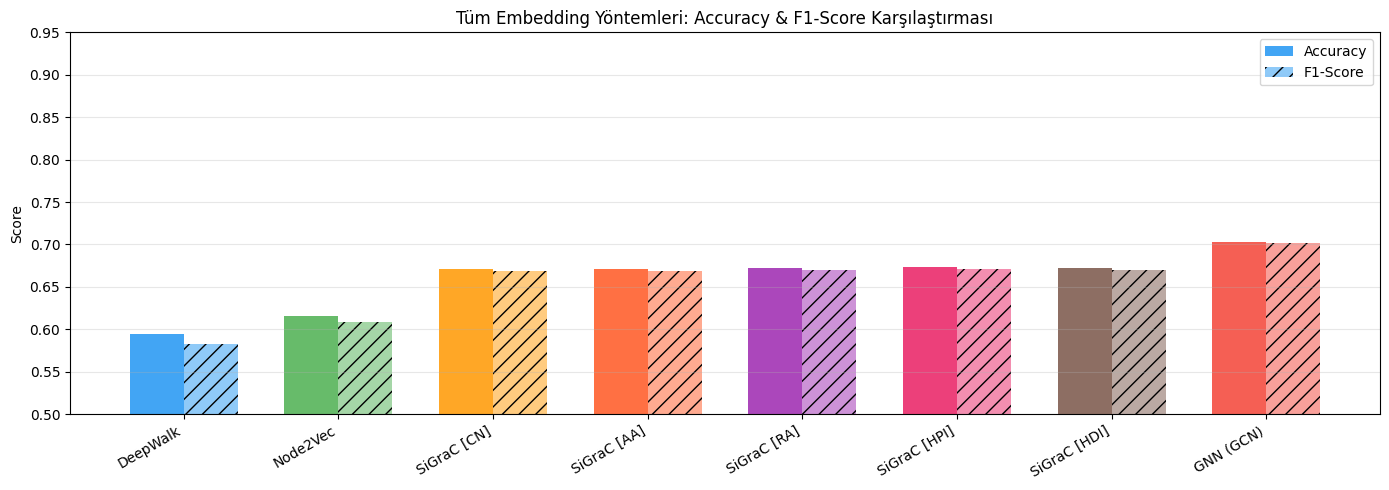

Grafik kaydedildi: all_methods_comparison.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = {
    "DeepWalk"      : "#2196F3",
    "Node2Vec"      : "#4CAF50",
    "SiGraC [CN]"   : "#FF9800",
    "SiGraC [AA]"   : "#FF5722",
    "SiGraC [RA]"   : "#9C27B0",
    "SiGraC [HPI]"  : "#E91E63",
    "SiGraC [HDI]"  : "#795548",
    "GNN (GCN)"     : "#F44336",
}

bar_colors = [colors.get(m, "#607D8B") for m in df_results["Method"]]
x = range(len(df_results))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_results["Accuracy"],
               width, label="Accuracy", color=bar_colors, alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], df_results["F1-Score"],
               width, label="F1-Score", color=bar_colors, alpha=0.5, hatch="//")

ax.set_xticks(list(x))
ax.set_xticklabels(df_results["Method"], rotation=30, ha="right")
ax.set_ylim(0.5, 0.95)
ax.set_ylabel("Score")
ax.set_title("Tüm Embedding Yöntemleri: Accuracy & F1-Score Karşılaştırması")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("all_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: all_methods_comparison.png")